In [1]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set()

In [2]:
# =========================================================
# STEP 1: DOWN-SAMPLING & SCALING (QUANTUM PREP)
# =========================================================

df_qkn_final = pd.read_csv('data/qkn_data.csv')
print("[PROC] Preparing and balancing data for the Quantum Circuit...")

# Separate the classes
df_failed = df_qkn_final[df_qkn_final['Target_Failure'] == 1]
df_safe = df_qkn_final[df_qkn_final['Target_Failure'] == 0]

# Down-sample the Safe class (2:1 ratio for efficient quantum simulation)
df_safe_sampled = df_safe.sample(n=len(df_failed) * 2, random_state=42)
df_qkn_balanced = pd.concat([df_failed, df_safe_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Isolate Features (X) and Target (y)
X_raw = df_qkn_balanced[['Grade', 'Pressure', 'Distance_to_Node_km']].values
y = df_qkn_balanced['Target_Failure'].values

# Split data first (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)

# Scale to [0, pi] for Quantum Angle Embedding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"-> Training Samples: {len(X_train_scaled)} | Testing Samples: {len(X_test_scaled)}\n")

[PROC] Preparing and balancing data for the Quantum Circuit...
-> Training Samples: 134 | Testing Samples: 34

[PROC] Preparing and balancing data for the Quantum Circuit...
-> Training Samples: 134 | Testing Samples: 34



In [3]:
df_failed

,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
2858,2024-09-01 14:00:00,新豐配電變電所,YAGI,3,1000.0,1381.852162,1
2877,2024-09-01 20:00:00,新豐配電變電所,YAGI,3,1000.0,1264.191953,1
2896,2024-09-02 02:00:00,新豐配電變電所,YAGI,3,996.0,1179.958478,1
3549,2024-09-15 20:00:00,成都變電所,BEBINCA,5,965.0,692.750820,1
3568,2024-09-16 02:00:00,成都變電所,BEBINCA,5,970.0,653.633854,1
3587,2024-09-16 08:00:00,成都變電所,BEBINCA,5,980.0,669.672716,1
3606,2024-09-16 14:00:00,成都變電所,BEBINCA,4,985.0,716.662735,1
3625,2024-09-16 20:00:00,成都變電所,BEBINCA,4,992.0,770.945983,1
3644,2024-09-17 02:00:00,成都變電所,BEBINCA,3,1000.0,832.869852,1
3663,2024-09-17 08:00:00,成都變電所,BEBINCA,2,1004.0,915.315323,1


,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
2858,2024-09-01 14:00:00,新豐配電變電所,YAGI,3,1000.0,1381.852162,1
2877,2024-09-01 20:00:00,新豐配電變電所,YAGI,3,1000.0,1264.191953,1
2896,2024-09-02 02:00:00,新豐配電變電所,YAGI,3,996.0,1179.958478,1
3549,2024-09-15 20:00:00,成都變電所,BEBINCA,5,965.0,692.750820,1
3568,2024-09-16 02:00:00,成都變電所,BEBINCA,5,970.0,653.633854,1
3587,2024-09-16 08:00:00,成都變電所,BEBINCA,5,980.0,669.672716,1
3606,2024-09-16 14:00:00,成都變電所,BEBINCA,4,985.0,716.662735,1
3625,2024-09-16 20:00:00,成都變電所,BEBINCA,4,992.0,770.945983,1
3644,2024-09-17 02:00:00,成都變電所,BEBINCA,3,1000.0,832.869852,1
3663,2024-09-17 08:00:00,成都變電所,BEBINCA,2,1004.0,915.315323,1


In [14]:
len(df_failed)

56

In [15]:
len(df_safe)

15499

In [4]:
df_safe

,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
0,2024-05-25 02:00:00,西螺服務區,EWINIAR,2,1004.0,1480.794552,0
1,2024-05-25 02:00:00,興變電所,EWINIAR,2,1004.0,1437.763521,0
2,2024-05-25 02:00:00,內惟配電變電所,EWINIAR,2,1004.0,1371.301527,0
3,2024-05-25 02:00:00,永華二次變電所,EWINIAR,2,1004.0,1407.368499,0
4,2024-05-25 02:00:00,四湖配電變電所,EWINIAR,2,1004.0,1473.112499,0
...,...,...,...,...,...,...,...
15550,2025-12-03 08:00:00,內惟配電變電所,KOTO,2,1010.0,1444.230756,0
15551,2025-12-03 08:00:00,永華二次變電所,KOTO,2,1010.0,1464.190790,0
15552,2025-12-03 08:00:00,新高港超高壓變電所,KOTO,2,1010.0,1445.906247,0
15553,2025-12-03 08:00:00,九曲配電變電所,KOTO,2,1010.0,1463.167230,0


,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
0,2024-05-25 02:00:00,西螺服務區,EWINIAR,2,1004.0,1480.794552,0
1,2024-05-25 02:00:00,興變電所,EWINIAR,2,1004.0,1437.763521,0
2,2024-05-25 02:00:00,內惟配電變電所,EWINIAR,2,1004.0,1371.301527,0
3,2024-05-25 02:00:00,永華二次變電所,EWINIAR,2,1004.0,1407.368499,0
4,2024-05-25 02:00:00,四湖配電變電所,EWINIAR,2,1004.0,1473.112499,0
...,...,...,...,...,...,...,...
15550,2025-12-03 08:00:00,內惟配電變電所,KOTO,2,1010.0,1444.230756,0
15551,2025-12-03 08:00:00,永華二次變電所,KOTO,2,1010.0,1464.190790,0
15552,2025-12-03 08:00:00,新高港超高壓變電所,KOTO,2,1010.0,1445.906247,0
15553,2025-12-03 08:00:00,九曲配電變電所,KOTO,2,1010.0,1463.167230,0


In [5]:
# =========================================================
# STEP 2: PENNYLANE QUANTUM CIRCUIT DEFINITION
# =========================================================
n_qubits = X_train_scaled.shape[1] # 3 features = 3 qubits

print(f"[PROC] Initializing device with {n_qubits} qubits...")
try:
    dev = qml.device("qiskit.aer", wires=n_qubits)
except qml.DeviceError:
    # Safe fallback if qiskit plugin isn't active
    dev = qml.device("default.qubit", wires=n_qubits) 

def feature_map(x):
    """Encodes classical data into a quantum state."""
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='X')
    # Entanglement layer (Ring structure)
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    """Calculates overlap |<psi(x1)|psi(x2)>|^2 (Compute-Uncompute)"""
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    # Probs of basis states; Index 0 is |000>
    return qml.probs(wires=range(n_qubits))

def qkn_matrix(A, B):
    """Constructs the classical kernel matrix by evaluating the quantum circuit."""
    matrix = np.zeros((len(A), len(B)))
    total_evals = len(A) * len(B)
    with tqdm(total=total_evals, desc="Computing Q-Kernel", unit="evals") as pbar:
        for i in range(len(A)):
            for j in range(len(B)):
                matrix[i, j] = kernel_circuit(A[i], B[j])[0]
                pbar.update(1)
    return matrix

[PROC] Initializing device with 3 qubits...
[PROC] Initializing device with 3 qubits...


[PROC] Text-based Circuit Diagram:
0: ─╭AngleEmbedding(M0)─╭●────╭X─╭X†─────╭X†─╭AngleEmbedding(M1)†─┤ ╭Probs
1: ─├AngleEmbedding(M0)─╰X─╭●─│──│───╭X†─╰X†─├AngleEmbedding(M1)†─┤ ├Probs
2: ─╰AngleEmbedding(M0)────╰X─╰●─╰X†─╰X†─────╰AngleEmbedding(M1)†─┤ ╰Probs

M0 = 
[0.78539816 2.59257646 2.51285162]
M1 = 
[2.35619449 1.37254048 0.41247194]
[PROC] Text-based Circuit Diagram:
0: ─╭AngleEmbedding(M0)─╭●────╭X─╭X†─────╭X†─╭AngleEmbedding(M1)†─┤ ╭Probs
1: ─├AngleEmbedding(M0)─╰X─╭●─│──│───╭X†─╰X†─├AngleEmbedding(M1)†─┤ ├Probs
2: ─╰AngleEmbedding(M0)────╰X─╰●─╰X†─╰X†─────╰AngleEmbedding(M1)†─┤ ╰Probs

M0 = 
[0.78539816 2.59257646 2.51285162]
M1 = 
[2.35619449 1.37254048 0.41247194]


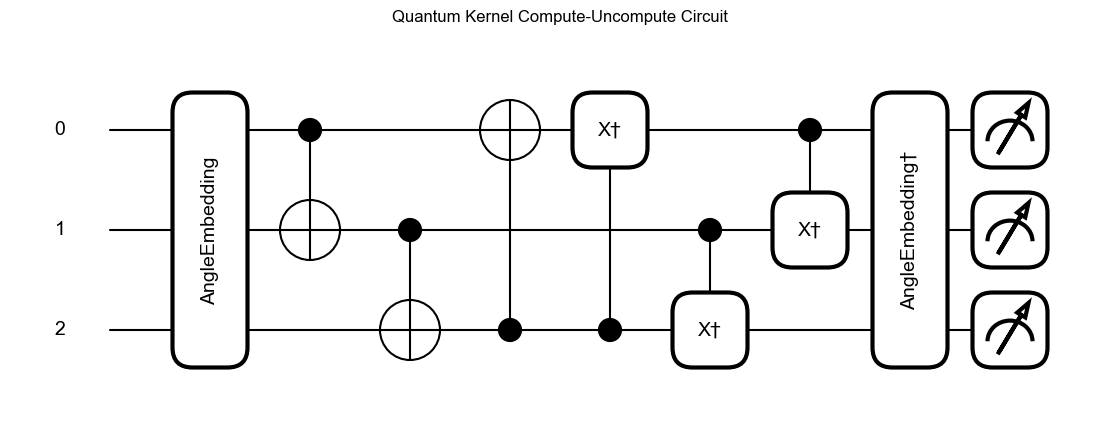

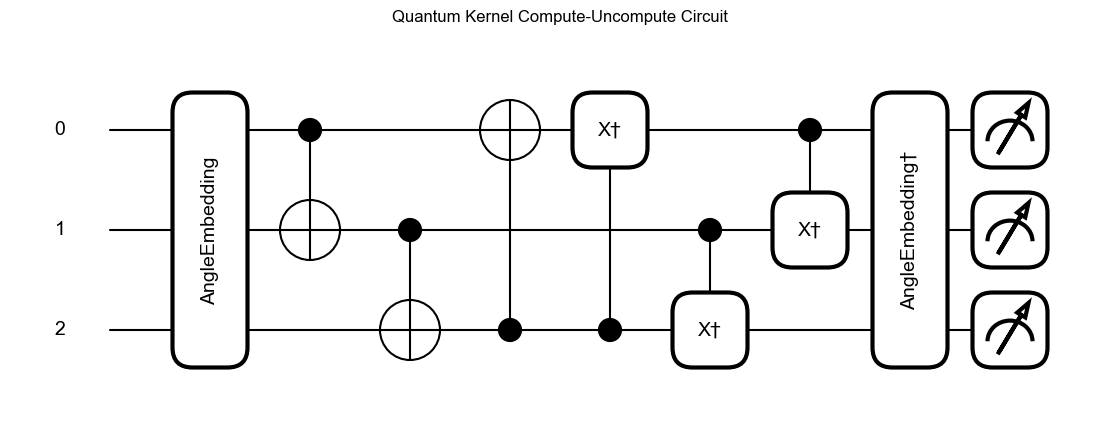

In [6]:
# =========================================================
# STEP 3: CIRCUIT VISUALIZATION
# =========================================================
sample_x1, sample_x2 = X_train_scaled[0], X_train_scaled[1]
print("[PROC] Text-based Circuit Diagram:")
print(qml.draw(kernel_circuit)(sample_x1, sample_x2))

# Render Matplotlib Graphic
fig, ax = qml.draw_mpl(kernel_circuit, decimals=2)(sample_x1, sample_x2)
plt.title("Quantum Kernel Compute-Uncompute Circuit")
plt.tight_layout()
plt.show(block=False)

In [7]:
# =========================================================
# STEP 4: KERNEL COMPUTATION & QSVC TRAINING
# =========================================================
print("\n[PROC] Computing quantum kernel matrix for training data")
K_train = qkn_matrix(X_train_scaled, X_train_scaled)

print("\n[PROC] Computing quantum kernel matrix for test data")
K_test = qkn_matrix(X_test_scaled, X_train_scaled)


[PROC] Computing quantum kernel matrix for training data


Computing Q-Kernel:   0%|          | 0/17956 [00:00<?, ?evals/s]


[PROC] Computing quantum kernel matrix for training data


Computing Q-Kernel:   0%|          | 0/17956 [00:00<?, ?evals/s]


[PROC] Computing quantum kernel matrix for test data


Computing Q-Kernel:   0%|          | 0/4556 [00:00<?, ?evals/s]

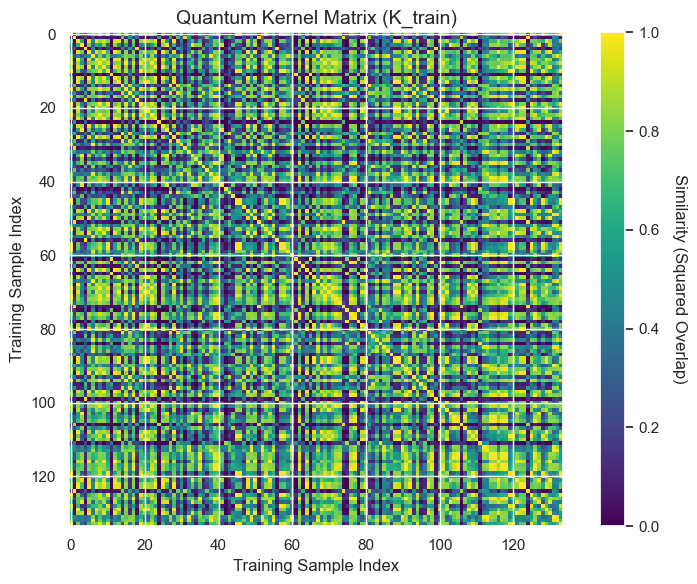

In [8]:
fig_k, ax_k = plt.subplots(figsize=(8, 6))

cax = ax_k.imshow(K_train, cmap='viridis', interpolation='nearest')
cbar = fig_k.colorbar(cax)
cbar.set_label('Similarity (Squared Overlap)', rotation=270, labelpad=20)

ax_k.set_title('Quantum Kernel Matrix (K_train)', fontsize=14)
ax_k.set_xlabel('Training Sample Index', fontsize=12)
ax_k.set_ylabel('Training Sample Index', fontsize=12)

plt.tight_layout()
plt.show()

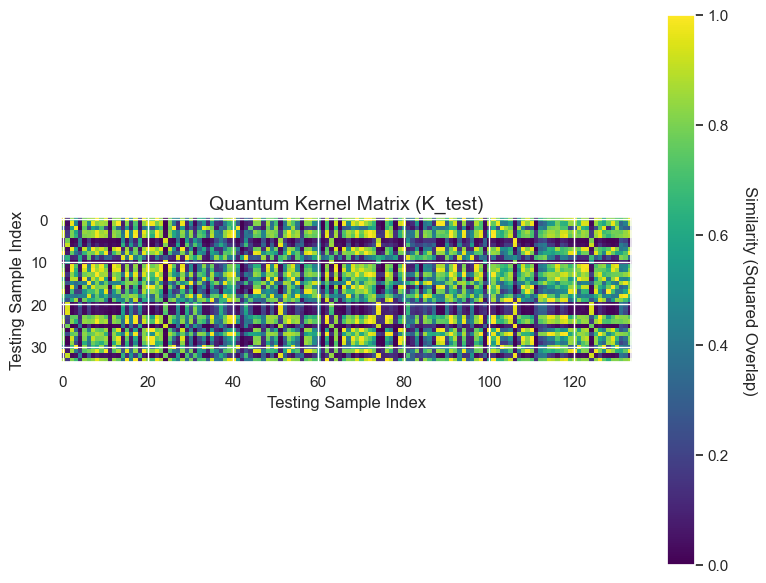

In [9]:
fig_k, ax_k = plt.subplots(figsize=(8, 6))

cax = ax_k.imshow(K_test, cmap='viridis', interpolation='nearest')
cbar = fig_k.colorbar(cax)
cbar.set_label('Similarity (Squared Overlap)', rotation=270, labelpad=20)

ax_k.set_title('Quantum Kernel Matrix (K_test)', fontsize=14)
ax_k.set_xlabel('Testing Sample Index', fontsize=12)
ax_k.set_ylabel('Testing Sample Index', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
print("\n[PROC] Training Quantum Support Vector Classifier (QSVC)")
# Using SVC instead of SVR for binary classification (0 or 1)
qsvc = SVC(kernel='precomputed', class_weight='balanced', C=1.0)
qsvc.fit(K_train, y_train)


print("\n[PROC] Making risk classifications")
y_pred = qsvc.predict(K_test)


[PROC] Training Quantum Support Vector Classifier (QSVC)

[PROC] Making risk classifications



=== QSVC PERFORMANCE REPORT ===
              precision    recall  f1-score   support

    Safe (0)       0.90      0.39      0.55        23
  Failed (1)       0.42      0.91      0.57        11

    accuracy                           0.56        34
   macro avg       0.66      0.65      0.56        34
weighted avg       0.74      0.56      0.55        34


Confusion Matrix:
[[ 9 14]
 [ 1 10]]


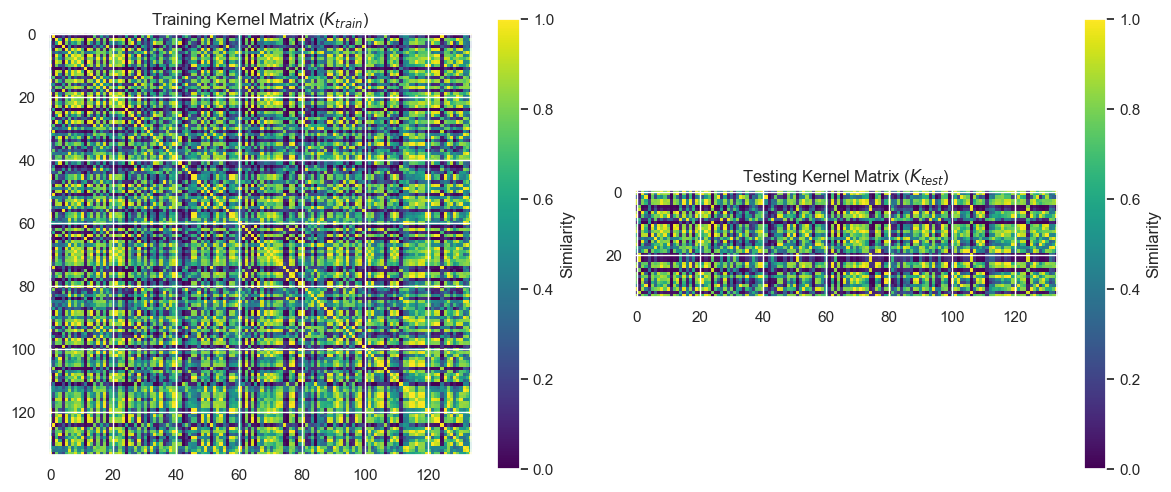

In [11]:
# =========================================================
# STEP 5: EVALUATION & HEATMAPS
# =========================================================
print("\n=== QSVC PERFORMANCE REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Failed (1)']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plot the Kernel Matrices
fig_k, axes_k = plt.subplots(1, 2, figsize=(12, 5))

cax1 = axes_k[0].imshow(K_train, cmap='viridis', interpolation='nearest')
fig_k.colorbar(cax1, ax=axes_k[0], label='Similarity')
axes_k[0].set_title('Training Kernel Matrix ($K_{train}$)')

cax2 = axes_k[1].imshow(K_test, cmap='viridis', interpolation='nearest')
fig_k.colorbar(cax2, ax=axes_k[1], label='Similarity')
axes_k[1].set_title('Testing Kernel Matrix ($K_{test}$)')

plt.tight_layout()
plt.show()

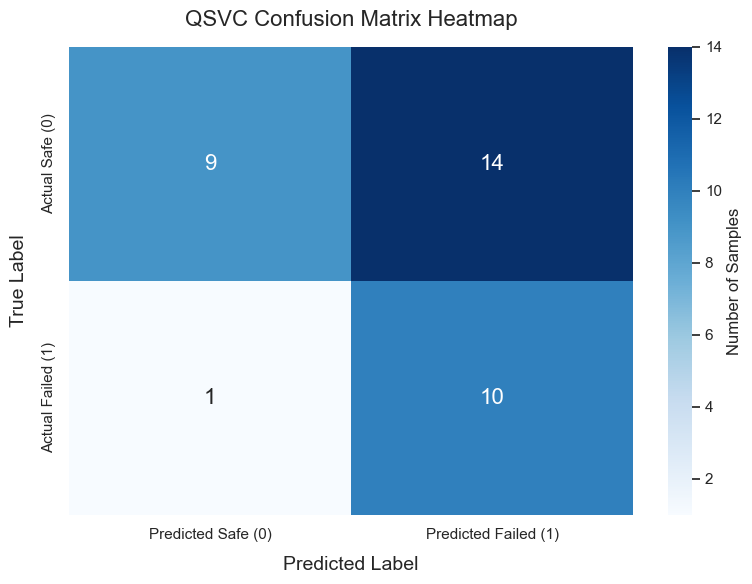

In [13]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# 3. Plot the heatmap using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Safe (0)', 'Predicted Failed (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Failed (1)'],
            annot_kws={"size": 16}, 
            cbar_kws={'label': 'Number of Samples'})

# 4. Add titles and labels for clarity
plt.title('QSVC Confusion Matrix Heatmap', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.ylabel('True Label', fontsize=14, labelpad=10)

# 5. Render
plt.tight_layout()
plt.show()